In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
from scipy.stats import wasserstein_distance
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys
sys.path.insert(
    1, "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation"
)
import plot_utils as plot
import numpy as np

import torch
import os

In [16]:
# old_ds_path = '/hkfs/work/workspace/scratch/xo8179-ukesm/global_1985_2014_equiangular_wp_conservative_40_chunks/fields.zarr'
old_ds_path = '/hkfs/work/workspace/scratch/xo8179-ukesm/global_2097_2100_equiangular_wp_conservative/fields.zarr'
# new_ds_path = '/hkfs/work/workspace/scratch/xo8179-ukesm/global_1985_2014_equiangular_wp_conservative_40_chunks_holes_filled/fields.zarr'
new_ds_path = '/hkfs/work/workspace/scratch/xo8179-ukesm/global_2097_2100_equiangular_wp_conservative_holes_filled/fields.zarr'

In [17]:
ds_old = plot.fix_lon_lat(xr.open_zarr(old_ds_path)).chunk({'longitude': -1, 'latitude':-1})

In [18]:
print(ds_old)

<xarray.Dataset> Size: 8GB
Dimensions:                      (time: 5760, longitude: 128, latitude: 64,
                                  level: 6)
Coordinates:
  * latitude                     (latitude) float64 512B -90.0 -87.14 ... 90.0
  * level                        (level) float32 24B 200.0 300.0 ... 850.0 925.0
  * longitude                    (longitude) float64 1kB 0.0 2.812 ... 357.2
  * time                         (time) object 46kB 2097-01-01 00:00:00 ... 2...
Data variables: (12/14)
    geopotential_500             (time, longitude, latitude) float32 189MB dask.array<chunksize=(720, 128, 64), meta=np.ndarray>
    geopotential_at_surface      (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    land_sea_mask                (longitude, latitude) float32 33kB dask.array<chunksize=(128, 64), meta=np.ndarray>
    mean_sea_level_pressure      (time, longitude, latitude) float32 189MB dask.array<chunksize=(720, 128, 64), meta=np.ndarray>
    re

In [19]:
mask = xr.open_zarr('/hkfs/home/project/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/valid_masks.zarr')

In [20]:
print(mask)

<xarray.Dataset> Size: 198kB
Dimensions:       (level: 3, longitude: 128, latitude: 64)
Coordinates:
  * latitude      (latitude) float64 512B -90.0 -87.14 -84.29 ... 87.14 90.0
  * level         (level) float32 12B 700.0 850.0 925.0
  * longitude     (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
Data variables:
    all_combined  (level, longitude, latitude) int64 197kB dask.array<chunksize=(3, 128, 64), meta=np.ndarray>


In [21]:
full_mask = mask.reindex(
    level=ds_old.level,  # complete level coordinate from the dataset
    fill_value=1         # fill missing levels with 0s (meaning: unaffected)
)

In [22]:
print(full_mask)
# full_mask.to_zarr('/hkfs/home/project/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/full_valid_mask.zarr')

<xarray.Dataset> Size: 395kB
Dimensions:       (latitude: 64, level: 6, longitude: 128)
Coordinates:
  * latitude      (latitude) float64 512B -90.0 -87.14 -84.29 ... 87.14 90.0
  * level         (level) float32 24B 200.0 300.0 500.0 700.0 850.0 925.0
  * longitude     (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
Data variables:
    all_combined  (level, longitude, latitude) int64 393kB dask.array<chunksize=(3, 128, 64), meta=np.ndarray>


In [23]:
level_vars = [v for v in ds_old.data_vars if 'level' in ds_old[v].dims]
surface_vars = [v for v in ds_old.data_vars if 'level' not in ds_old[v].dims]

In [24]:
ds_old_filtered = ds_old[level_vars].where(full_mask['all_combined'], drop=False)

ds_old_filtered_interpolated = (
    ds_old_filtered
    .ffill('longitude')
    .bfill('longitude')
    .ffill('latitude')
    .bfill('latitude')
    
)

In [25]:
surface = ds_old[surface_vars]

# Merge back
ds_filtered = xr.merge([ds_old_filtered_interpolated, surface])

In [26]:
print(ds_filtered)

<xarray.Dataset> Size: 8GB
Dimensions:                      (latitude: 64, level: 6, longitude: 128,
                                  time: 5760)
Coordinates:
  * latitude                     (latitude) float64 512B -90.0 -87.14 ... 90.0
  * level                        (level) float32 24B 200.0 300.0 ... 850.0 925.0
  * longitude                    (longitude) float64 1kB 0.0 2.812 ... 357.2
  * time                         (time) object 46kB 2097-01-01 00:00:00 ... 2...
Data variables: (12/14)
    relative_vorticity           (time, level, longitude, latitude) float32 1GB dask.array<chunksize=(40, 3, 128, 64), meta=np.ndarray>
    specific_humidity            (time, level, longitude, latitude) float32 1GB dask.array<chunksize=(40, 3, 128, 64), meta=np.ndarray>
    temperature                  (time, level, longitude, latitude) float32 1GB dask.array<chunksize=(40, 3, 128, 64), meta=np.ndarray>
    u_component_of_wind          (time, level, longitude, latitude) float32 1GB dask.array

In [27]:
print(ds_filtered['temperature'].sel(level=850).isel(time=0))

<xarray.DataArray 'temperature' (longitude: 128, latitude: 64)> Size: 33kB
dask.array<getitem, shape=(128, 64), dtype=float32, chunksize=(128, 64), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 512B -90.0 -87.14 -84.29 ... 84.29 87.14 90.0
    level      float32 4B 850.0
  * longitude  (longitude) float64 1kB 0.0 2.812 5.625 ... 351.6 354.4 357.2
    time       object 8B 2097-01-01 00:00:00
Attributes:
    date:           01/01/15
    long_name:      Temperature T
    name:           temp
    source:         Unified Model Output (Vn11.2):
    standard_name:  air_temperature
    time:           00:00
    title:          Temperature T
    units:          K
    valid_max:      314.69580078125
    valid_min:      0.0


/hkfs/home/project/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


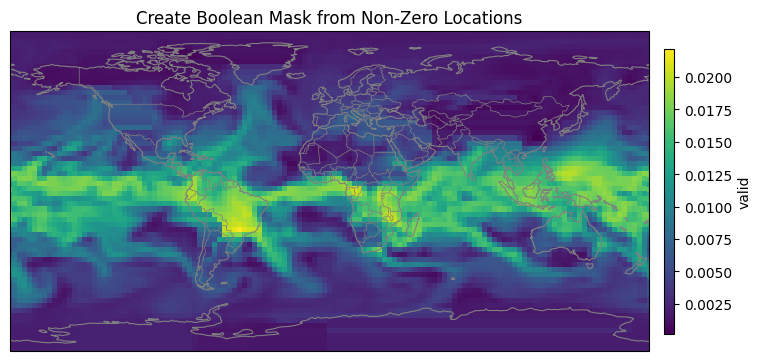

In [28]:
plot.plot_single_plot(ds_filtered['specific_humidity'].sel(level=850).isel(time=0).T, f'Create Boolean Mask from Non-Zero Locations', 'valid', None, 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", f'step_2', show=True)

In [29]:
ds_filtered.to_zarr(new_ds_path, mode='w')